## Dating App Behavior: Dataset 2025👩‍❤️‍👨

[Kaggle Data Source](https://www.kaggle.com/datasets/keyushnisar/dating-app-behavior-dataset)


Data Overview:

With dating apps becoming a primary avenue for forming romantic connections understanding user behavior is increasingly valuable. The behavior on these platforms is influenced by a complex web of demographic, personal, and usage-based factors. 

- Contains 50,000 entries and includes $25$ features such as:

         - Demographics: gender, age, height, weight, zodiac sign, sexual orientation, education level, income bracket
         - Behavioral Data: app usage time, swipe patterns, emoji usage, time of day activity
         - Profile Infromation: intrest tags, bio length, number of profile pictures 
         - Engagment Matrics: like received, mutual matches, messages sent
         - Outcome Data: labeled outcomes like Mutual Match, Date Happened, No Action, etc.
         
The Objective:
- Predict the match outcome (`match_outcome`) for a user based on user demographics, profile traits, and app behabior.

- This target variable includes classes such as:

             - Mutual Match
             - Date Happened 
             - One-sided Like
             - No Action
             - Chat Ignored       
- Helps platforms refine matching algorithms to boost satisfaction and retention
- Flag potantially concerning or harmful behavior patterns
- Support between onboarding and user recommendations


In [40]:
# Imports 
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.neural_network import MLPClassifier
from sklearn.compose import make_column_selector as selector

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [45]:
# Loading the Data
df = pd.read_csv('dating_app_behavior_dataset_extended1.csv', sep=',')

display(df.head(5)) # Loads the first 5 rows
print("df shape:", df.shape) # Dimensions       

# Display basic info
df.info()

,gender,sexual_orientation,location_type,income_bracket,education_level,interest_tags,app_usage_time_min,app_usage_time_label,swipe_right_ratio,swipe_right_label,...,emoji_usage_rate,last_active_hour,swipe_time_of_day,match_outcome,age,height_cm,weight_kg,zodiac_sign,body_type,relationship_intent
0,Prefer Not to Say,Gay,Urban,High,Bachelor’s,"Fitness, Politics, Traveling",52,Moderate,0.60,Optimistic,...,0.36,13,Early Morning,Mutual Match,56,149,40.6,Taurus,Curvy,Friends Only
1,Male,Bisexual,Suburban,Upper-Middle,No Formal Education,"Languages, Fashion, Parenting",279,Extreme User,0.56,Optimistic,...,0.42,0,Morning,Chat Ignored,40,155,69.7,Leo,Plus Size,Hookups
2,Non-binary,Pansexual,Suburban,Low,Master’s,"Movies, Reading, DIY",49,Moderate,0.41,Optimistic,...,0.41,1,After Midnight,Date Happened,30,185,96.9,Sagittarius,Curvy,Serious Relationship
3,Genderfluid,Gay,Metro,Very Low,Postdoc,"Coding, Podcasts, History",185,Extreme User,0.32,Balanced,...,0.07,21,Morning,No Action,57,154,49.3,Taurus,Slim,Exploring
4,Male,Bisexual,Urban,Middle,Bachelor’s,"Clubbing, Podcasts, Cars",83,High,0.32,Balanced,...,0.11,22,After Midnight,One-sided Like,24,149,40.0,Libra,Slim,Casual Dating


df shape: (50000, 25)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   gender                50000 non-null  object 
 1   sexual_orientation    50000 non-null  object 
 2   location_type         50000 non-null  object 
 3   income_bracket        50000 non-null  object 
 4   education_level       50000 non-null  object 
 5   interest_tags         50000 non-null  object 
 6   app_usage_time_min    50000 non-null  int64  
 7   app_usage_time_label  50000 non-null  object 
 8   swipe_right_ratio     50000 non-null  float64
 9   swipe_right_label     50000 non-null  object 
 10  likes_received        50000 non-null  int64  
 11  mutual_matches        50000 non-null  int64  
 12  profile_pics_count    50000 non-null  int64  
 13  bio_length            50000 non-null  int64  
 14  message_sent_count    50000 non-null  int64  
 1

In [17]:
# Checks for missing Value in the data
#df.isnull().sum

/tmp/ipykernel_129593/1284352312.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=match_outcome_counts.index, y=match_outcome_counts.values, ax=axes[0], palette="viridis")
/tmp/ipykernel_129593/1284352312.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)
/tmp/ipykernel_129593/1284352312.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=usage_by_intent.values, y=usage_by_intent.index, ax=axes[1], palette="magma")


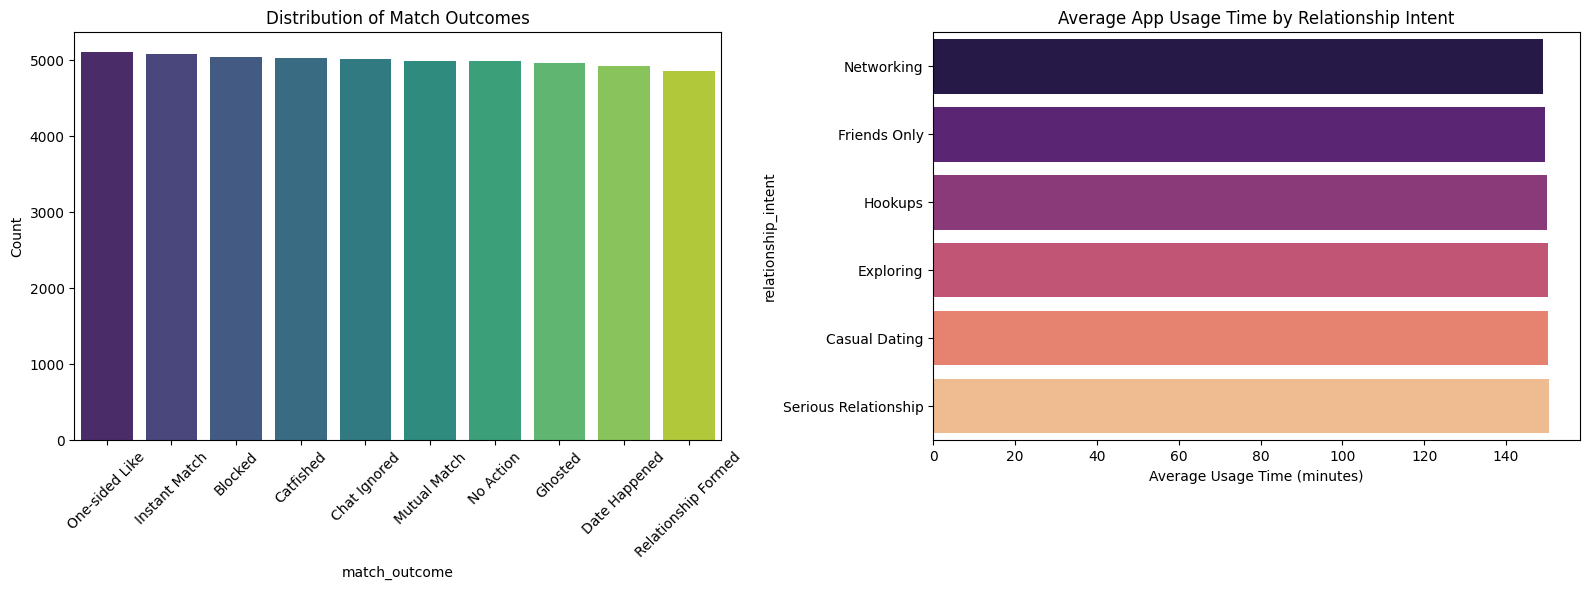

In [46]:
# Summarize a few of the categorical and numerical columns
categorical_summary = df[['gender', 'sexual_orientation', 'relationship_intent', 'match_outcome']].value_counts().head(10)
numerical_summary = df[['app_usage_time_min', 'swipe_right_ratio', 'likes_received', 'mutual_matches']].describe()

# Visualizations

# True match outcome distribution (counts per category)
match_outcome_counts = df['match_outcome'].value_counts()

# Average app usage time by relationship intent
usage_by_intent = df.groupby('relationship_intent')['app_usage_time_min'].mean().sort_values()

# Create plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Match outcome distribution
sns.barplot(x=match_outcome_counts.index, y=match_outcome_counts.values, ax=axes[0], palette="viridis")
axes[0].set_title("Distribution of Match Outcomes")
axes[0].set_ylabel("Count")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)

# Plot 2: App usage time by relationship intent
sns.barplot(x=usage_by_intent.values, y=usage_by_intent.index, ax=axes[1], palette="magma")
axes[1].set_title("Average App Usage Time by Relationship Intent")
axes[1].set_xlabel("Average Usage Time (minutes)")

plt.tight_layout()
plt.show()


# K Means

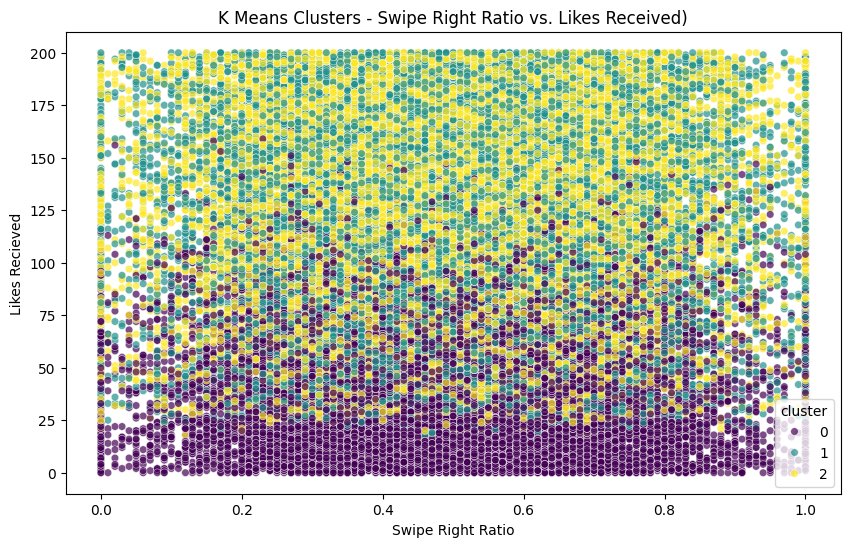

In [47]:
#Select features for clustering
features = df[['app_usage_time_min', 'swipe_right_ratio', 'likes_received', 'mutual_matches']]

#Standardizing
scaler = StandardScaler()
x_scaled = scaler.fit_transform(features)

#KMeans
kmeans = KMeans(n_clusters = 3, random_state = 42)
df['cluster'] = kmeans.fit_predict(x_scaled)

#Scatterplot
plt.figure(figsize = (10, 6))
sns.scatterplot(x = df['swipe_right_ratio'], y = df['likes_received'], hue = df['cluster'], palette = 'viridis', s = 30, alpha = 0.7)
plt.title("K Means Clusters - Swipe Right Ratio vs. Likes Received)")
plt.xlabel("Swipe Right Ratio")
plt.ylabel("Likes Recieved")
plt.show()

_Notes:_ This plot shows clear clusters which show the swipe right ratio is not a significant factor in user engagement, but likes recieved is. 

# Principal Component Analysis - PCA

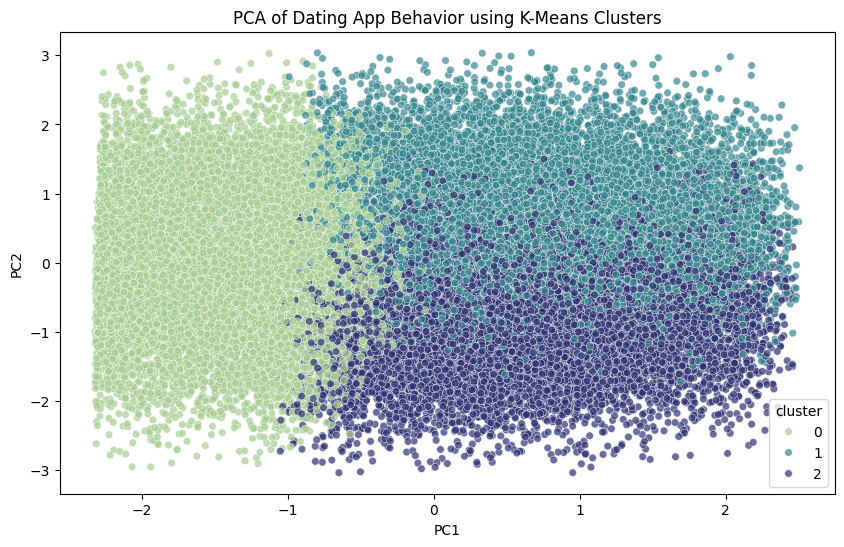

In [48]:
# PCA
pca = PCA(n_components = 2)
pca_components = pca.fit_transform(x_scaled)
df['PC1'] = pca_components[:, 0]
df['PC2'] = pca_components[:, 1]

# Scatterplot PCA clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PC1', y='PC2', hue='cluster', data=df, palette='crest', s = 30, alpha = 0.7)
plt.title("PCA of Dating App Behavior using K-Means Clusters")
plt.show()

_Notes:_ The PCA plot shows that while our cluster graph showed a large amount of overlap, the groups are more distinct than previously shown. 

# Random Foresst


In [57]:

# Combine similar outcome classes
outcome_map = {
    "Mutual Match": "Match",
    "Date Happened": "Match",
    "One-sided Like": "Low Interest",
    "Chat Ignored": "Low Interest",
    "No Action": "No Engagement"
}

df['match_outcome_grouped'] = df['match_outcome'].map(outcome_map)

# Drop original outcome and sparse/uninformative columns
df_edit = df.drop(columns=[col for col in ['match_outcome', 'interest_tags'] if col in df.columns]) # assume 'interest_tags' is sparse text


# Encode categorical features
categorical_cols = df_edit.select_dtypes(include='object').columns
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_edit[col] = le.fit_transform(df_edit[col])
    label_encoders[col] = le
# print(X.dtypes) # double-checks types 

    
# Define features and new target
X = df_edit.drop(columns=['match_outcome_grouped'])
y = LabelEncoder().fit_transform(df['match_outcome_grouped'])

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ------------------- Random Forest -------------------
rf = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_preds)
rf_report = classification_report(y_test, rf_preds, output_dict=True)

# ------------------- ANN (MLPClassifier) -------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

mlp = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=300, random_state=42)
mlp.fit(X_train_scaled, y_train)
mlp_preds = mlp.predict(X_test_scaled)
mlp_acc = accuracy_score(y_test, mlp_preds)
mlp_report = classification_report(y_test, mlp_preds, output_dict=True)

def classification_report_to_df(report_dict, model_name):
    df = pd.DataFrame(report_dict).transpose().reset_index()
    df = df.rename(columns={'index': 'class'})
    df = df[['class', 'precision', 'recall', 'f1-score']]  # focus on key metrics
    df['model'] = model_name
    return df

# Convert reports
rf_report_df = classification_report_to_df(rf_report, 'Random Forest')
mlp_report_df = classification_report_to_df(mlp_report, 'MLPClassifier')

# Combine into one table
report_table = pd.concat([rf_report_df, mlp_report_df], ignore_index=True)

# Optional: round for display
report_table[['precision', 'recall', 'f1-score']] = report_table[['precision', 'recall', 'f1-score']].round(2)

# Display
print(report_table)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


           class  precision  recall  f1-score          model
0              0       0.00    0.00      0.00  Random Forest
1              1       0.00    0.00      0.00  Random Forest
2              2       0.00    0.00      0.00  Random Forest
3              3       0.50    1.00      0.67  Random Forest
4       accuracy       0.50    0.50      0.50  Random Forest
5      macro avg       0.13    0.25      0.17  Random Forest
6   weighted avg       0.25    0.50      0.34  Random Forest
7              0       0.21    0.19      0.20  MLPClassifier
8              1       0.20    0.17      0.18  MLPClassifier
9              2       0.09    0.03      0.05  MLPClassifier
10             3       0.50    0.61      0.55  MLPClassifier
11      accuracy       0.38    0.38      0.38  MLPClassifier
12     macro avg       0.25    0.25      0.24  MLPClassifier
13  weighted avg       0.34    0.38      0.36  MLPClassifier


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


Notes: The table shows that both models struggled with class imbalance. The Random Forest predicted only one outcome well (50% accuracy), while the MLPClassifier offered more balanced predictions but lower overall accuracy (38%).